# Pirámide poblacional comparativa

Compara la estructura demográfica de tres escalas territoriales:
**Local**, **Barrio** e **Intermunicipal**.

Los valores se expresan como **porcentaje del total de población de cada entorno**,
lo que hace comparables territorios de tamaños absolutamente distintos.

> **Fuente:** INEGI, Censo de Población y Vivienda 2020 — SCINCE

---

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

## Configuración
Ajusta aquí las rutas y el estilo visual.

In [2]:
# --- Rutas ---
DATA_PATH = 'C:/Users/COMIMSA/Desktop/SECTEI/CDITVallejo/datos/00_insumos/manzanas_zonaestudio.gpkg'

# --- Estilo global ---
FONTSIZE = 10
DPI      = 150

# Colores por sexo (consistentes en todas las gráficas)
COLOR_H = '#2196F3'   # azul — hombres
COLOR_M = '#E91E63'   # rosa  — mujeres

# Colores por entorno (para la gráfica superpuesta)
COLORES_ENTORNO = {
    'Local':          '#1B5E20',   # verde oscuro
    'Barrio':         '#E65100',   # naranja
    'Intermunicipal': '#4A148C',   # morado
}

## Carga y segmentación de datos

In [3]:
mzn = gpd.read_file(DATA_PATH)

# Reemplazar códigos de no disponible (-8) y confidencial (-6) por NaN
mzn_clean = mzn.replace([-8, -6], np.nan)

# Los entornos son anidados: Barrio contiene a Local; Intermunicipal contiene a ambos.
local          = mzn_clean[mzn['entorno'] == 'Local']
barrio         = mzn_clean[mzn['entorno'].isin(['Barrio', 'Local'])]
intermunicipal = mzn_clean[mzn['entorno'].isin(['Intermunicipal', 'Barrio', 'Local'])]

print(f"Local:          {len(local):,} manzanas  (solo entorno Local)")
print(f"Barrio:         {len(barrio):,} manzanas  (Barrio + Local)")
print(f"Intermunicipal: {len(intermunicipal):,} manzanas  (Intermunicipal + Barrio + Local)")

Local:          102 manzanas  (solo entorno Local)
Barrio:         596 manzanas  (Barrio + Local)
Intermunicipal: 6,857 manzanas  (Intermunicipal + Barrio + Local)


## Mapeo de columnas por grupo de edad y sexo

Columnas identificadas en el notebook de exploración a partir de los
descriptores SCINCE 2020. Los grupos de edad son:

| Grupo | Años | Nota |
|-------|------|------|
| 0-2   | 3 años | — |
| 3-5   | 3 años | — |
| 6-11  | 6 años | — |
| 12-14 | 3 años | — |
| 15-17 | 3 años | — |
| 18-24 | 7 años | — |
| 25-29 | 5 años | — |
| **30-49** | **20 años** | Grupo amplio; barra naturalmente más alta |
| 50-59 | 10 años | — |
| 60-64 | 5 años | — |
| 65-69 | 5 años | — |
| 70-74 | 5 años | — |
| 75-79 | 5 años | — |
| 80-84 | 5 años | — |

In [4]:
ORDEN_GRUPOS = [
    '0-2', '3-5', '6-11', '12-14', '15-17', '18-24', '25-29',
    '30-49', '50-59', '60-64', '65-69', '70-74', '75-79', '80-84'
]

COLS_HOMBRES = {
    '0-2':   'POB85',  '3-5':   'POB87',  '6-11':  'POB88',  '12-14': 'POB90',
    '15-17': 'POB92',  '18-24': 'POB96',  '25-29': 'POB113', '30-49': 'POB97',
    '50-59': 'POB98',  '60-64': 'POB99',  '65-69': 'POB120', '70-74': 'POB121',
    '75-79': 'POB122', '80-84': 'POB123'
}

COLS_MUJERES = {
    '0-2':   'POB43',  '3-5':   'POB45',  '6-11':  'POB46',  '12-14': 'POB48',
    '15-17': 'POB50',  '18-24': 'POB55',  '25-29': 'POB72',  '30-49': 'POB56',
    '50-59': 'POB57',  '60-64': 'POB58',  '65-69': 'POB79',  '70-74': 'POB80',
    '75-79': 'POB81',  '80-84': 'POB82'
}

## Funciones auxiliares

In [5]:
def sumar_col(df, col):
    """Suma segura de una columna, ignorando NaN."""
    if col is None:
        return 0.0
    if isinstance(col, tuple):  # diferencia de columnas
        return df[col[0]].sum(skipna=True) - df[col[1]].sum(skipna=True)
    return df[col].sum(skipna=True)


def calcular_porcentajes(df):
    """
    Calcula el porcentaje que representa cada grupo de edad y sexo
    respecto al total de población del entorno.

    Returns
    -------
    pct_h, pct_m : np.ndarray
        Arrays con los porcentajes por grupo, en el orden de ORDEN_GRUPOS.
    """
    abs_h = np.array([sumar_col(df, COLS_HOMBRES.get(g)) for g in ORDEN_GRUPOS])
    abs_m = np.array([sumar_col(df, COLS_MUJERES.get(g)) for g in ORDEN_GRUPOS])
    total = abs_h.sum() + abs_m.sum()
    if total == 0:
        return np.zeros_like(abs_h, dtype=float), np.zeros_like(abs_m, dtype=float)
    return abs_h / total * 100, abs_m / total * 100

## Cálculo de porcentajes y resumen

In [6]:
entornos_df = {
    'Local':          local,
    'Barrio':         barrio,
    'Intermunicipal': intermunicipal,
}

datos = {}
resumen_rows = []

for nombre, df in entornos_df.items():
    pct_h, pct_m = calcular_porcentajes(df)
    abs_h = np.array([sumar_col(df, COLS_HOMBRES.get(g)) for g in ORDEN_GRUPOS])
    abs_m = np.array([sumar_col(df, COLS_MUJERES.get(g)) for g in ORDEN_GRUPOS])
    total = abs_h.sum() + abs_m.sum()

    datos[nombre] = {'pct_h': pct_h, 'pct_m': pct_m}

    resumen_rows.append({
        'Entorno':       nombre,
        'Manzanas':      len(df),
        'Población total': int(total),
        'Hombres':       int(abs_h.sum()),
        'Mujeres':       int(abs_m.sum()),
        '% Hombres':     round(abs_h.sum() / total * 100, 1),
        '% Mujeres':     round(abs_m.sum() / total * 100, 1),
    })

resumen = pd.DataFrame(resumen_rows).set_index('Entorno')
resumen

,Manzanas,Población total,Hombres,Mujeres,% Hombres,% Mujeres
Entorno,,,,,,
Local,102,19806,9452,10354,47.7,52.3
Barrio,596,110867,52788,58079,47.6,52.4
Intermunicipal,6857,852731,403826,448905,47.4,52.6


---
## Pirámide comparativa — tres paneles

Tres pirámides en porcentaje con el mismo rango en el eje x,
lo que permite comparar directamente la forma de cada estructura.

In [7]:
def piramide_3paneles(datos, orden_grupos,
                      titulo='Comparación de estructuras demográficas por entorno',
                      archivo='piramide_comparativa_3paneles.png'):
    """
    Dibuja tres pirámides poblacionales en porcentaje en un mismo lienzo.
    Todos los paneles comparten el mismo eje y y la misma escala x.
    """
    nombres = list(datos.keys())
    y = np.arange(len(orden_grupos))

    # Escala x global: mismo límite para todos los paneles
    max_pct = max(
        max(datos[n]['pct_h'].max(), datos[n]['pct_m'].max())
        for n in nombres
    ) * 1.18

    fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)
    fig.subplots_adjust(wspace=0.06)

    for ax, nombre in zip(axes, nombres):
        pct_h = datos[nombre]['pct_h']
        pct_m = datos[nombre]['pct_m']

        ax.barh(y, -pct_h, height=0.72, color=COLOR_H, alpha=0.88, zorder=2)
        ax.barh(y,  pct_m, height=0.72, color=COLOR_M, alpha=0.88, zorder=2)

        # Etiquetas de valor en cada barra
        for i, (vh, vm) in enumerate(zip(pct_h, pct_m)):
            if vh > 0.3:
                ax.text(-vh - max_pct * 0.01, i, f'{vh:.1f}', va='center', ha='right',
                        fontsize=FONTSIZE - 2, color='#1565C0')
            if vm > 0.3:
                ax.text( vm + max_pct * 0.01, i, f'{vm:.1f}', va='center', ha='left',
                        fontsize=FONTSIZE - 2, color='#880E4F')

        ax.axvline(0, color='black', linewidth=0.9, zorder=3)
        ax.set_xlim(-max_pct, max_pct)
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{abs(x):.0f}%')
        )
        ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', labelsize=FONTSIZE - 1)
        ax.tick_params(axis='y', labelsize=FONTSIZE)

        color_tit = COLORES_ENTORNO.get(nombre, 'black')
        ax.set_title(nombre, fontsize=FONTSIZE + 3, fontweight='bold',
                     color=color_tit, pad=8)
        ax.set_xlabel('% de la población del entorno', fontsize=FONTSIZE)

        # Indicadores H/M en primer panel
        if nombre == nombres[0]:
            ax.text(-max_pct * 0.96, len(orden_grupos) - 0.2, '← Hombres',
                    fontsize=FONTSIZE - 1, color=COLOR_H, fontweight='bold', ha='left')
            ax.text( max_pct * 0.96, len(orden_grupos) - 0.2, 'Mujeres →',
                    fontsize=FONTSIZE - 1, color=COLOR_M, fontweight='bold', ha='right')

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(orden_grupos, fontsize=FONTSIZE)
    axes[0].set_ylabel('Grupo de edad', fontsize=FONTSIZE + 1)

    # Leyenda global centrada
    patch_h = mpatches.Patch(color=COLOR_H, label='Hombres')
    patch_m = mpatches.Patch(color=COLOR_M, label='Mujeres')
    fig.legend(handles=[patch_h, patch_m], loc='lower center',
               ncol=2, fontsize=FONTSIZE + 1, frameon=False,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(titulo, fontsize=FONTSIZE + 4, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(archivo, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"Guardado: '{archivo}'")

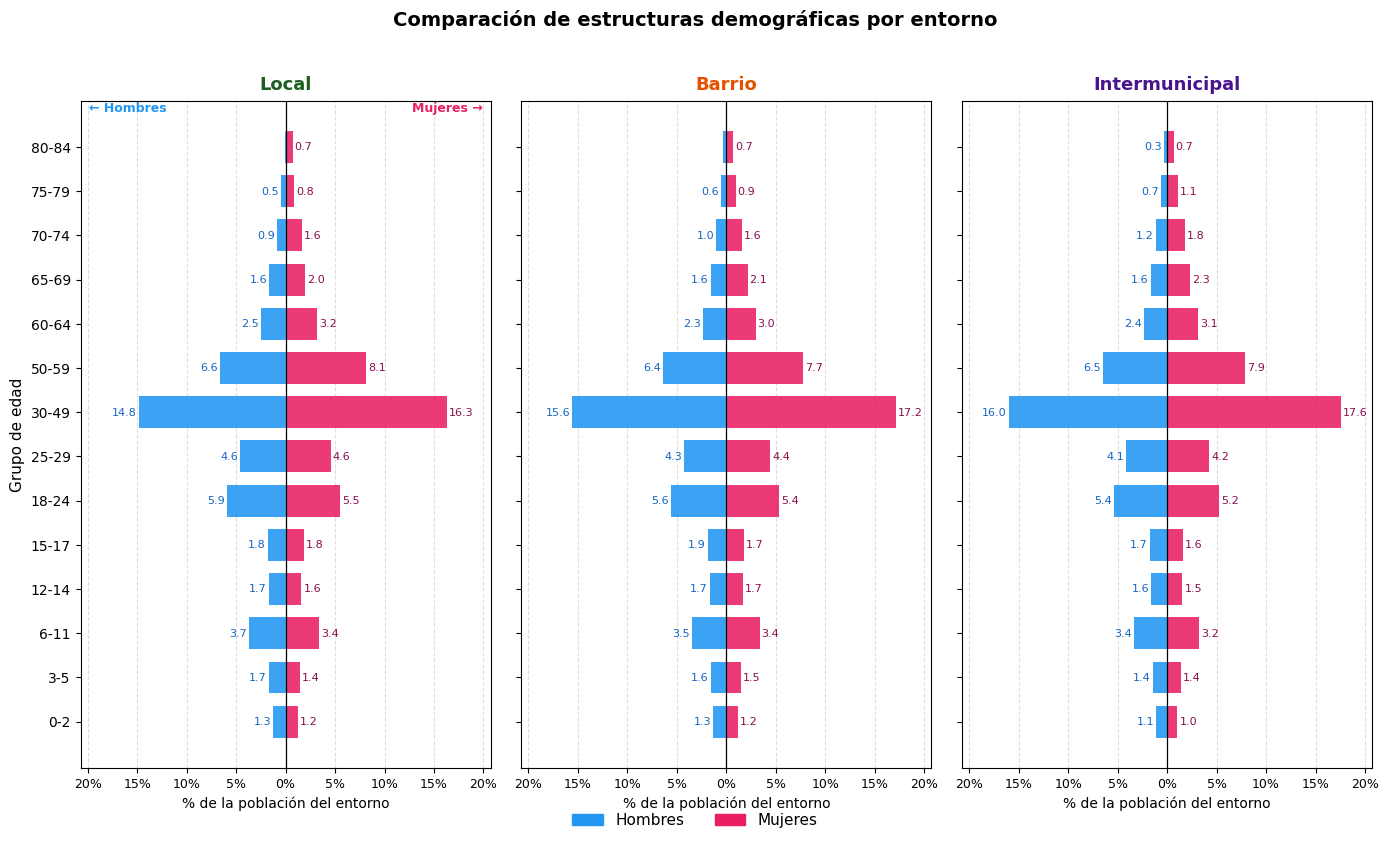

Guardado: 'piramide_comparativa_3paneles.png'


In [8]:
piramide_3paneles(datos, ORDEN_GRUPOS)

---
## Pirámide superpuesta

Los tres entornos se muestran en un único panel con barras agrupadas.
Permite detectar diferencias de forma global en un solo vistazo.

In [ ]:
def piramide_superpuesta(datos, orden_grupos,
                         titulo='Superposición de estructuras demográficas',
                         archivo='piramide_comparativa_superpuesta.png'):
    """
    Dibuja las tres estructuras demográficas superpuestas en un único panel.
    Usa barras agrupadas (offset vertical) con colores por entorno.
    """
    y = np.arange(len(orden_grupos))
    n_entornos = len(datos)

    bar_h   = 0.22
    offsets = np.linspace(-(n_entornos - 1) / 2, (n_entornos - 1) / 2, n_entornos) * bar_h

    max_pct = max(
        max(datos[n]['pct_h'].max(), datos[n]['pct_m'].max())
        for n in datos
    ) * 1.15

    fig, ax = plt.subplots(figsize=(9, 8))

    handles = []
    for i, (nombre, vals) in enumerate(datos.items()):
        color  = COLORES_ENTORNO.get(nombre, f'C{i}')
        offset = offsets[i]

        ax.barh(y + offset, -vals['pct_h'], height=bar_h,
                color=color, alpha=0.72, edgecolor=color, linewidth=0.6, zorder=2)
        ax.barh(y + offset,  vals['pct_m'], height=bar_h,
                color=color, alpha=0.72, edgecolor=color, linewidth=0.6, zorder=2)

        handles.append(mpatches.Patch(color=color, label=nombre))

    ax.axvline(0, color='black', linewidth=1, zorder=3)
    ax.set_xlim(-max_pct, max_pct)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{abs(x):.0f}%')
    )
    ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    ax.set_yticks(y)
    ax.set_yticklabels(orden_grupos, fontsize=FONTSIZE)
    ax.set_ylabel('Grupo de edad', fontsize=FONTSIZE + 1)
    ax.set_xlabel('% de la población del entorno', fontsize=FONTSIZE + 1)
    ax.tick_params(axis='x', labelsize=FONTSIZE - 1)

    # Indicadores H / M
    ax.text(-max_pct * 0.97, len(orden_grupos) - 0.3, '← Hombres',
            fontsize=FONTSIZE, color=COLOR_H, fontweight='bold', ha='left')
    ax.text( max_pct * 0.97, len(orden_grupos) - 0.3, 'Mujeres →',
            fontsize=FONTSIZE, color=COLOR_M, fontweight='bold', ha='right')

    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.1),
              ncol=3, fontsize=FONTSIZE + 1, frameon=False)

    ax.set_title(titulo, fontsize=FONTSIZE + 3, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.savefig(archivo, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"Guardado: '{archivo}'")

In [ ]:
piramide_superpuesta(datos, ORDEN_GRUPOS)

---
## Perfil demográfico — curvas comparadas

Cada entorno se representa como una curva de área.
Este formato resalta diferencias en la **forma** de la distribución
(pirámide expansiva, estacionaria, regresiva), abstrayendo el volumen.

In [ ]:
def perfil_demografico(datos, orden_grupos,
                       titulo='Perfil demográfico comparado',
                       archivo='piramide_comparativa_perfil.png'):
    """
    Panel doble (Hombres | Mujeres) con una curva de área por entorno.
    El eje x de Hombres está invertido para mantener la lectura de pirámide.
    """
    y = np.arange(len(orden_grupos))

    fig, (ax_h, ax_m) = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
    fig.subplots_adjust(wspace=0.04)

    for nombre, vals in datos.items():
        color  = COLORES_ENTORNO.get(nombre, 'gray')
        pct_h  = vals['pct_h']
        pct_m  = vals['pct_m']

        for ax, pct in [(ax_h, pct_h), (ax_m, pct_m)]:
            ax.plot(pct, y, '-o', color=color, linewidth=2, markersize=4,
                    label=nombre, zorder=3)
            ax.fill_betweenx(y, 0, pct, color=color, alpha=0.14)

    for ax, label, color_lbl in [
        (ax_h, 'Hombres', COLOR_H),
        (ax_m, 'Mujeres', COLOR_M)
    ]:
        ax.xaxis.grid(True, linestyle='--', alpha=0.4)
        ax.set_axisbelow(True)
        ax.set_xlabel(f'% del total — {label}', fontsize=FONTSIZE + 1)
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.1f}%')
        )
        ax.tick_params(axis='x', labelsize=FONTSIZE - 1)
        ax.text(0.98, 0.98, label, transform=ax.transAxes,
                ha='right', va='top', fontsize=FONTSIZE + 1,
                fontweight='bold', color=color_lbl)

    ax_h.invert_xaxis()   # Hombres crece hacia la izquierda
    ax_h.set_yticks(y)
    ax_h.set_yticklabels(orden_grupos, fontsize=FONTSIZE)
    ax_h.set_ylabel('Grupo de edad', fontsize=FONTSIZE + 1)

    # Leyenda única en el panel derecho
    handles = [
        mpatches.Patch(color=COLORES_ENTORNO[n], label=n)
        for n in datos
    ]
    ax_m.legend(handles=handles, loc='lower right',
                fontsize=FONTSIZE + 1, frameon=False)

    fig.suptitle(titulo, fontsize=FONTSIZE + 4, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(archivo, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"Guardado: '{archivo}'")

In [ ]:
perfil_demografico(datos, ORDEN_GRUPOS)

---
## Tabla detallada por entorno

Porcentajes de cada grupo de edad y sexo para los tres entornos.

In [ ]:
rows = []
for grupo in ORDEN_GRUPOS:
    row = {'Grupo': grupo}
    for nombre, vals in datos.items():
        idx = ORDEN_GRUPOS.index(grupo)
        row[f'{nombre} — H%'] = round(vals['pct_h'][idx], 2)
        row[f'{nombre} — M%'] = round(vals['pct_m'][idx], 2)
    rows.append(row)

tabla = pd.DataFrame(rows).set_index('Grupo')
tabla